In [1]:
from dynamicTasteDistortion.ioUtils import read_experiment
from dynamicTasteDistortion.simulationConstants import (
    input_size_to_file_name,
    RESULTS_PATH,
)
import pandas as pd

# Click position analysis


In this notebook I'll look at the average click position for each algorithm and the average number of interaction per round

In [39]:
bpr_debiased = "experiments/ml/bpr_unbiased_uncalibrated_large.yaml"
# Calibrated ones

bpr_debiased_calibrated_constant = "experiments/bpr_unbiased_calibrated_constant_large.yaml"
bpr_debiased_calibrated_time = "experiments/bpr_unbiased_calibrated_time_based_large.yaml"


In [40]:
bpr_debiased_exp = read_experiment(bpr_debiased)

In [45]:
bpr_debiased_exp

{'size': 's',
 'data': 'ml',
 'rounds': 10000,
 'num_rounds_per_eval': 250,
 'num_users': 1000,
 'model': 'bpr',
 'preference_update_rate': 0.1,
 'exp_name': 'bpr_unbiased_uncalibrated_large',
 'params': {'factors': 64,
  'lr': 0.0001,
  'reg_lambda': 1e-05,
  'num_negatives': 10,
  'n_epochs': 10}}

In [41]:
from dynamicTasteDistortion.ioUtils import get_oracle_matrix_path


data_type = bpr_debiased_exp["data"]
size = bpr_debiased_exp["size"]
file_size = input_size_to_file_name[size]
num_users = int(bpr_debiased_exp["num_users"])

preference_matrix_path = get_oracle_matrix_path(data_type, file_size, num_users)

In [42]:
oracle = pd.read_pickle(preference_matrix_path)

In [43]:
oracle

,user,item,rating,genres
0,94,0,1,"[animation, children's, comedy]"
1,138,0,1,"[animation, children's, comedy]"
2,560,0,1,"[animation, children's, comedy]"
3,647,0,1,"[animation, children's, comedy]"
4,855,0,1,"[animation, children's, comedy]"
...,...,...,...,...
3436995,69,2804,1,[comedy]
3436996,69,2805,1,[drama]
3436997,69,2806,1,[drama]
3436998,69,2807,1,[drama]


In [44]:
oracle["rating"].value_counts()

rating
1    2059256
0    1377744
Name: count, dtype: int64

<Axes: >

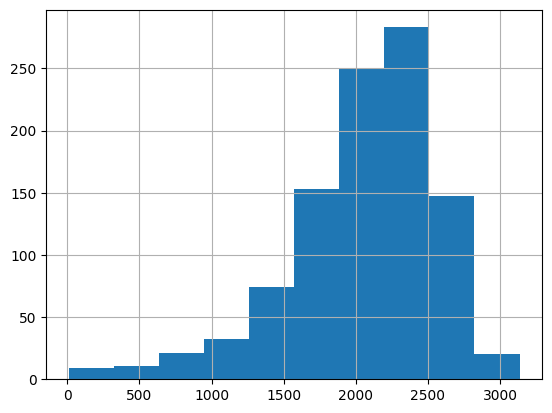

In [47]:
oracle[oracle["rating"] == 1].groupby("user").size().hist()

In [7]:
bpr_debiased_exp

{'size': 's',
 'data': 'ml',
 'rounds': 500,
 'num_rounds_per_eval': 5,
 'num_users': 1000,
 'model': 'bpr',
 'preference_update_rate': 0.1,
 'exp_name': 'bpr_unbiased_uncalibrated'}

In [8]:
from pathlib import Path


def get_experiment_artifact_path(cfg):
    rounds = int(cfg["rounds"])
    num_rounds_per_eval = int(cfg["num_rounds_per_eval"])
    num_users = int(cfg["num_users"])

    data_type = cfg["data"]
    size = cfg["size"]
    file_size = input_size_to_file_name[size]
    exp_name = cfg.get("exp_name", "default_experiment")

    base_artifacts_path = (
        Path(RESULTS_PATH)
        / f"{data_type}_{file_size}"
        / "simulated"
        / f"exp={exp_name}"
        / f"rounds={rounds}"
        / f"users={num_users}"
        / f"eval_every={num_rounds_per_eval}"
    )

    return str(base_artifacts_path)

In [9]:
path = get_experiment_artifact_path(bpr_debiased_exp)

In [10]:
simulation_df = pd.read_pickle(f"{path}/simulated_interactions.pkl")

In [11]:
simulation_df

,user,item,relevant,clicked_at,timestamp,rating,constant,linear_time,round
0,0,2519,1.0,0,0.878877,1.275901e-01,1,1.275901e-01,1
1,0,486,1.0,1,0.356013,2.469779e-02,1,9.988547e-03,1
2,0,299,1.0,2,0.000953,2.061583e-02,1,0.000000e+00,1
3,0,942,1.0,6,0.388004,7.588993e-03,1,3.345763e-03,1
4,0,1364,1.0,11,0.285008,1.000000e-08,1,3.235535e-09,1
...,...,...,...,...,...,...,...,...,...
30071,908,1621,1.0,7,110.676384,1.000000e-08,1,0.000000e+00,500
30072,925,832,1.0,18,114.384717,1.000000e-08,1,0.000000e+00,500
30073,939,2256,1.0,6,73.567786,1.000000e-08,1,0.000000e+00,500
30074,970,2874,1.0,5,129.076491,1.000000e-08,1,0.000000e+00,500


<Axes: >

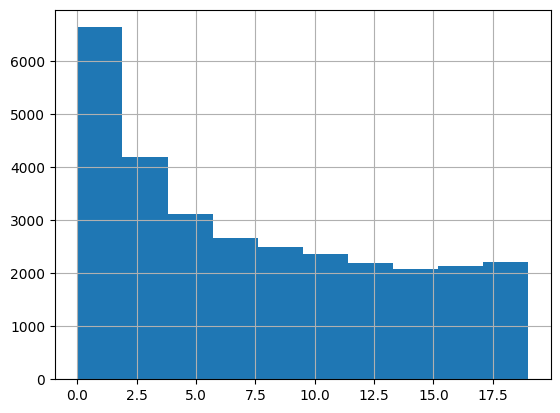

In [18]:
simulation_df["clicked_at"].hist()

## Number of interactions per user per round

In [19]:
simulation_df

,user,item,relevant,clicked_at,timestamp,rating,constant,linear_time,round
0,0,2519,1.0,0,0.878877,1.275901e-01,1,1.275901e-01,1
1,0,486,1.0,1,0.356013,2.469779e-02,1,9.988547e-03,1
2,0,299,1.0,2,0.000953,2.061583e-02,1,0.000000e+00,1
3,0,942,1.0,6,0.388004,7.588993e-03,1,3.345763e-03,1
4,0,1364,1.0,11,0.285008,1.000000e-08,1,3.235535e-09,1
...,...,...,...,...,...,...,...,...,...
30071,908,1621,1.0,7,110.676384,1.000000e-08,1,0.000000e+00,500
30072,925,832,1.0,18,114.384717,1.000000e-08,1,0.000000e+00,500
30073,939,2256,1.0,6,73.567786,1.000000e-08,1,0.000000e+00,500
30074,970,2874,1.0,5,129.076491,1.000000e-08,1,0.000000e+00,500


In [24]:
num_users = int(bpr_debiased_exp["num_users"])
interactions_per_round = (
    simulation_df.groupby("round")
    .size()
    .div(num_users)
)

In [25]:
interactions_per_round

round
1      2.891
2      1.228
3      0.880
4      0.683
5      0.528
       ...  
496    0.031
497    0.037
498    0.035
499    0.037
500    0.033
Length: 500, dtype: float64

In [22]:
import seaborn as sns

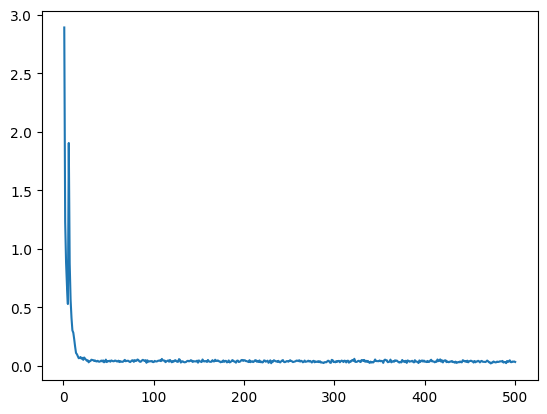

In [26]:
plt.plot(interactions_per_round)

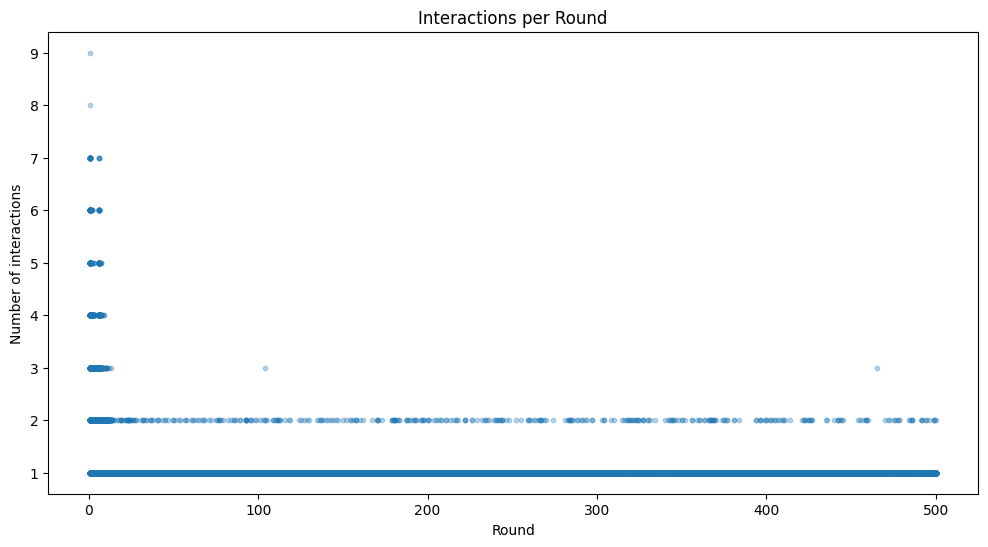

In [23]:
data = interactions_per_round[["round", "item"]]


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(data["round"], data["item"], alpha=0.3, s=10)
plt.xlabel("Round")
plt.ylabel("Number of interactions")
plt.title("Interactions per Round")
plt.show()